In [1]:
%load_ext autoreload
%autoreload 2

from pklib.indicators import *
from pklib.utilities import *
from pklib.pkindicators import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
# import pkindicators  # Assuming your C module is compiled and installed as pkindicators

# Generate sample data (you should replace this with real OHLCV data)
# dates = pd.date_range('2022-01-01', periods=1000, freq='D')
# prices = np.random.randn(1000).cumsum() + 100  # Simulated price data
# data = pd.DataFrame(prices, columns=['close'], index=dates)

import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

In [2]:

import sysconfig
cmodule = 'pkindicators'
f'clear & rm {cmodule}.so & gcc -shared -o {cmodule}.so -fPIC {cmodule}.c -I{sysconfig.get_path("include")} -I{np.get_include()}'

'clear & rm pkindicators.so & gcc -shared -o pkindicators.so -fPIC pkindicators.c -I/home/mu6mula/miniconda3/envs/py310/include/python3.10 -I/home/mu6mula/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/include'

In [3]:
# fib_levels = np.array([-1.0, -0.786, -0.618, -0.5, -0.414, -0.382, -0.236, 0.0, 0.236, 0.382, 0.414, 0.5, 0.618, 0.786, 1.0, 1.236, 1.5, 1.618, 1.786, 2.0, 2.236, 2.382, 2.5, 2.628, 2.786, 3, 3.382, 3.618, 4, 5])
fib_levels = np.array([-1.0, -0.786, -0.618, -0.5, -0.414, -0.382, -0.236, 0.0, 0.236, 0.382, 0.414, 0.5, 0.618, 0.786, 1.0, 1.236, 1.414, 1.5, 1.618, 1.786, 2.0])

fib_columns = [f'fib({fib})' for fib in fib_levels]
# fib_columns 
from collections import namedtuple

FibData = namedtuple('FibData', [
    'fib_levels_array', 'df_fibs', 'running_highs_idx', 'running_lows_idx',
    'running_highs', 'running_lows', 'directions', 'high_low_markers',
    'turning_points', 'turning_points_idx'
])


def calculate_fib_levels(data, epsilon, fib_levels=fib_levels):
    
    # Call the calculate_zigzag function from the C module
    high_low_markers, turning_points = calculate_zigzag(data['close'].values, data['close'].values, epsilon=epsilon)
    

    # Store the results back into the DataFrame for easier plotting
    data['HighLowMarkers'] = high_low_markers
    data['TurningPoints'] = turning_points

    # Get the indices of highs and lows
    highs_idx = data.index[data['HighLowMarkers'] == 1]
    lows_idx = data.index[data['HighLowMarkers'] == -1]

    running_highs = (np.where(high_low_markers == 1, 1, np.nan) * data['close']).ffill()
    running_lows = (np.where(high_low_markers == -1, 1, np.nan) * data['close']).ffill()

    running_highs_idx = pd.Series(np.where(high_low_markers == 1, 1, np.nan) * np.arange(len(data)), index=data.index).ffill()
    running_lows_idx = pd.Series(np.where(high_low_markers == -1, 1, np.nan) * np.arange(len(data)), index=data.index).ffill()


    directions = ((running_highs_idx > running_lows_idx) * 2 - 1)
    # Combine the indices and sort them
    turning_points_idx = sorted(highs_idx.union(lows_idx))

    # Calculate Fibonacci levels (assuming calculate_fib_levels and fib_columns are defined)
    # fibs = calculate_fib_levels(running_lows, running_highs, ((running_highs_idx > running_lows_idx) * 2 - 1))
    
    # Ensure highs, lows, and directions are numpy arrays
    # highs = np.asarray(highs)
    # lows = np.asarray(lows)
    # directions = np.asarray(directions)

    # Flip highs and lows based on direction (-1 means flip)
    adjusted_highs = np.where(directions == 1, running_highs, running_lows)
    adjusted_lows = np.where(directions == 1, running_lows, running_highs)

    # Calculate the difference between adjusted high and low
    diff = adjusted_highs - adjusted_lows

    # Calculate the Fibonacci levels by applying the levels to the differences
    fib_matrix = np.outer(diff, fib_levels)
    
    # Calculate the actual levels by adding them to the low (base) level
    fib_levels_array = adjusted_lows[:, np.newaxis] + fib_matrix
    
    df_fibs = pd.DataFrame(fib_levels_array, columns=fib_columns, index=data.index)

    # return fib_levels_array, df_fibs, running_highs_idx, running_lows_idx, running_highs, running_lows, directions, high_low_markers, turning_points, turning_points_idx
    
    return FibData(
        fib_levels_array=fib_levels_array,
        df_fibs=df_fibs,
        running_highs_idx=running_highs_idx,
        running_lows_idx=running_lows_idx,
        running_highs=running_highs,
        running_lows=running_lows,
        directions=directions,
        high_low_markers=high_low_markers,
        turning_points=turning_points,
        turning_points_idx=turning_points_idx,
    )


In [4]:
exchange,base,quote,timeframe = 'binance','ETH', 'USDT', '4h'
ws, ww = -400, 300
data = load_candles(exchange,base,quote,timeframe).apply(np.log)
epsilon = 0.1 

wdata = data.iloc[ws:ws+ww-1].copy()
# Call the calculate_zigzag function from the C module
high_low_markers, turning_points = calculate_zigzag(wdata['close'].values, wdata['close'].values, epsilon=epsilon)
high_low_markers, turning_points

(array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0, 

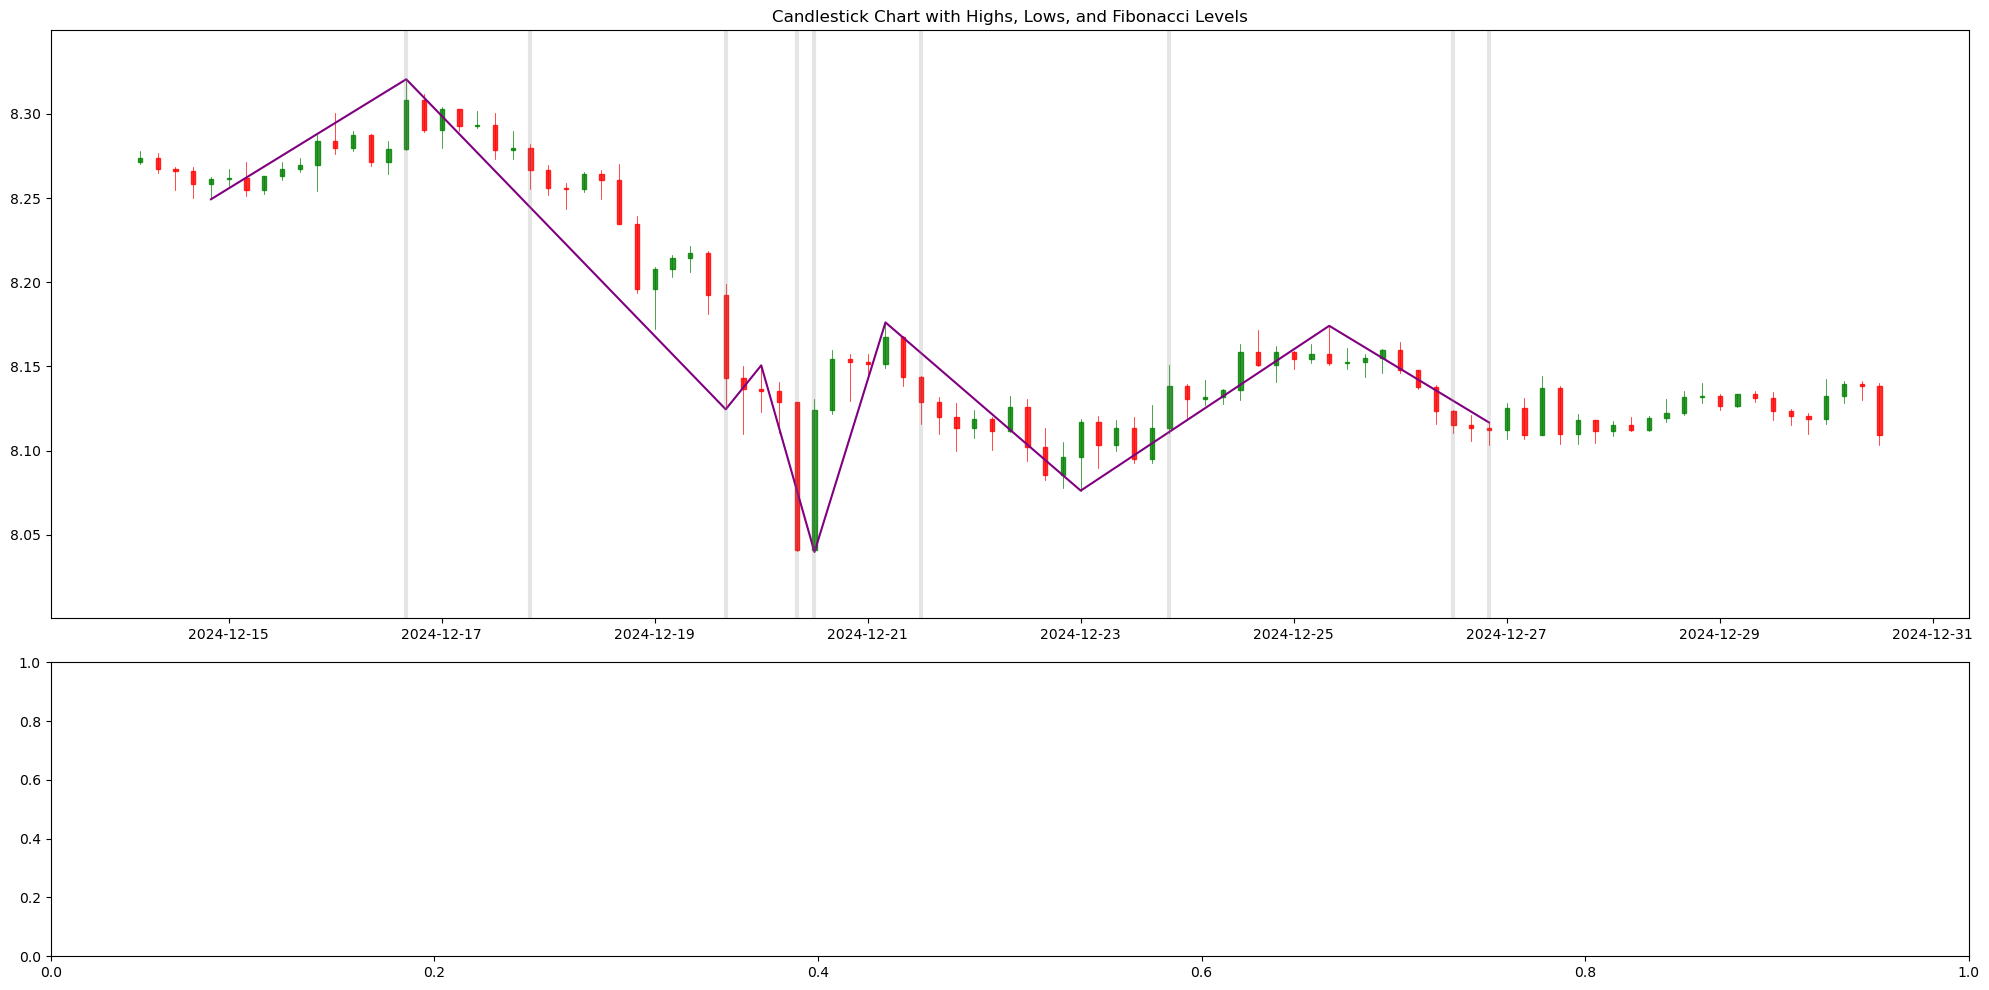

In [5]:
exchange,base,quote,timeframe = 'binance','ETH', 'USDT', '4h'
ws, ww = -400, 100
data = load_candles(exchange,base,quote,timeframe).apply(np.log)
epsilon = 0.06
wdata = data.iloc[ws:ws+ww-1].copy()
highs = wdata['high'].values
lows = wdata['low'].values
# Call the calculate_zigzag function from the C module
high_low_markers, turning_markers = calculate_zigzag(highs, lows, epsilon=epsilon)

extreme_points_ix = np.where(high_low_markers != 0)[0]
extreme_points = high_low_markers[extreme_points_ix]
extreme_prices = np.where(extreme_points == 1, highs[extreme_points_ix], lows[extreme_points_ix])

turning_points_ix = np.where(turning_markers !=0)[0]

# # Store the results back into the DataFrame for easier plotting
# wdata['HighLowMarkers'] = high_low_markers
# wdata['TurningPoints'] = turning_points

# # # Get the indices of highs and lows
# highs_idx = wdata.index[wdata['HighLowMarkers'] == 1]
# lows_idx = wdata.index[wdata['HighLowMarkers'] == -1]

# running_highs = pd.Series(np.where(high_low_markers == 1, 1, np.nan) * highs).ffill()
# running_lows = pd.Series(np.where(high_low_markers == -1, 1, np.nan) * lows).ffill()

# running_highs_idx = pd.Series(np.where(high_low_markers == 1, 1, np.nan) * np.arange(len(wdata)), index=wdata.index).ffill()
# running_lows_idx = pd.Series(np.where(high_low_markers == -1, 1, np.nan) * np.arange(len(wdata)), index=wdata.index).ffill()


# directions = ((running_highs_idx > running_lows_idx) * 2 - 1)
# Combine the indices and sort them
# turning_points_idx = sorted(highs_idx.union(lows_idx))

# Calculate Fibonacci levels (assuming calculate_fib_levels and fib_columns are defined)
# fibs = calculate_fib_levels(running_lows, running_highs, ((running_highs_idx > running_lows_idx) * 2 - 1))

# Ensure highs, lows, and directions are numpy arrays
# highs = np.asarray(highs)
# lows = np.asarray(lows)
# directions = np.asarray(directions)

# Flip highs and lows based on direction (-1 means flip)
# adjusted_highs = np.where(directions == 1, running_highs, running_lows)
# adjusted_lows = np.where(directions == 1, running_lows, running_highs)

# Calculate the difference between adjusted high and low
# diff = adjusted_highs - adjusted_lows

# Calculate the Fibonacci levels by applying the levels to the differences
# fib_matrix = np.outer(diff, fib_levels)

# Calculate the actual levels by adding them to the low (base) level
# fib_levels_array = adjusted_lows[:, np.newaxis] + fib_matrix

# df_fibs = pd.DataFrame(fib_levels_array, columns=fib_columns, index=wdata.index)

candlestick_ohlc_args={'width': .18 / np.log(len(wdata))}

##############################################
# Create the figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), height_ratios=[2, 1])

wdata['date_num'] = mdates.date2num(wdata.index)
# Prepare the OHLC data in the format: (date, open, high, low, close)
ohlc = wdata[['date_num', 'open', 'high', 'low', 'close']].values
# Plot the candlesticks
candlestick_ohlc(ax1, ohlc, colorup='green', colordown='red', alpha=0.8, **candlestick_ohlc_args)
# Set y-axis limits based on the close price
ax1.set_ylim(wdata['close'].min()*0.995, wdata['close'].max()*1.005)

# Format the x-axis to show dates
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.set_title('Candlestick Chart with Highs, Lows, and Fibonacci Levels')
# ax1.legend()

# turning_dates = mdates.date2num(wdata.loc[turning_points_idx].index)
ax1.plot(wdata.index[extreme_points_ix], extreme_prices, color='purple', label='ZigZag Line', lw=1.5)
for ix in turning_points_ix:
    ax1.axvline(wdata.index.values[ix], color='gray', linestyle='-', alpha=0.2, lw=3)

# df_fibs.plot(ax=ax1, linestyle='--', lw=1)

plt.tight_layout()
plt.show()

In [ ]:
# turning_markers
turning_points_ix